In [30]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns

df = pl.read_parquet("out/*.parquet", missing_columns='insert')

df

iterations,invalidation_method,page_number,compressed_size,uncompressed_size,compression_time,decompression_time,version,trace,alg,iter,inv
i64,i64,i64,i64,i64,i64,i64,i32,str,str,str,str
1,1,1,4208,4096,43201,11512,1,"""spec-all""","""WKdm""","""1""","""clflush"""
1,1,2,4168,4096,18240,10693,1,"""spec-all""","""WKdm""","""1""","""clflush"""
1,1,3,4172,4096,17876,7107,1,"""spec-all""","""WKdm""","""1""","""clflush"""
1,1,4,4192,4096,12525,7245,1,"""spec-all""","""WKdm""","""1""","""clflush"""
1,1,5,4216,4096,12137,6053,1,"""spec-all""","""WKdm""","""1""","""clflush"""
…,…,…,…,…,…,…,…,…,…,…,…
null,null,8163,2739,4096,12955,4084,3,"""spec-all""","""lz4""","""1""","""clflush"""
null,null,8164,1962,4096,11769,3620,3,"""spec-all""","""lz4""","""1""","""clflush"""
null,null,8165,695,4096,6318,2767,3,"""spec-all""","""lz4""","""1""","""clflush"""


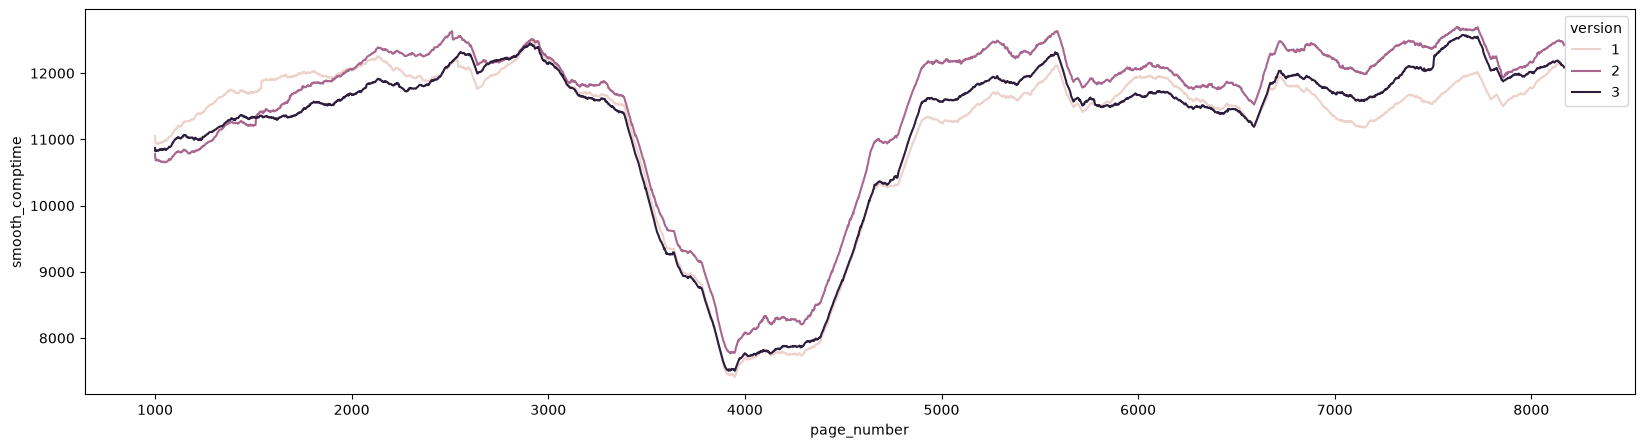

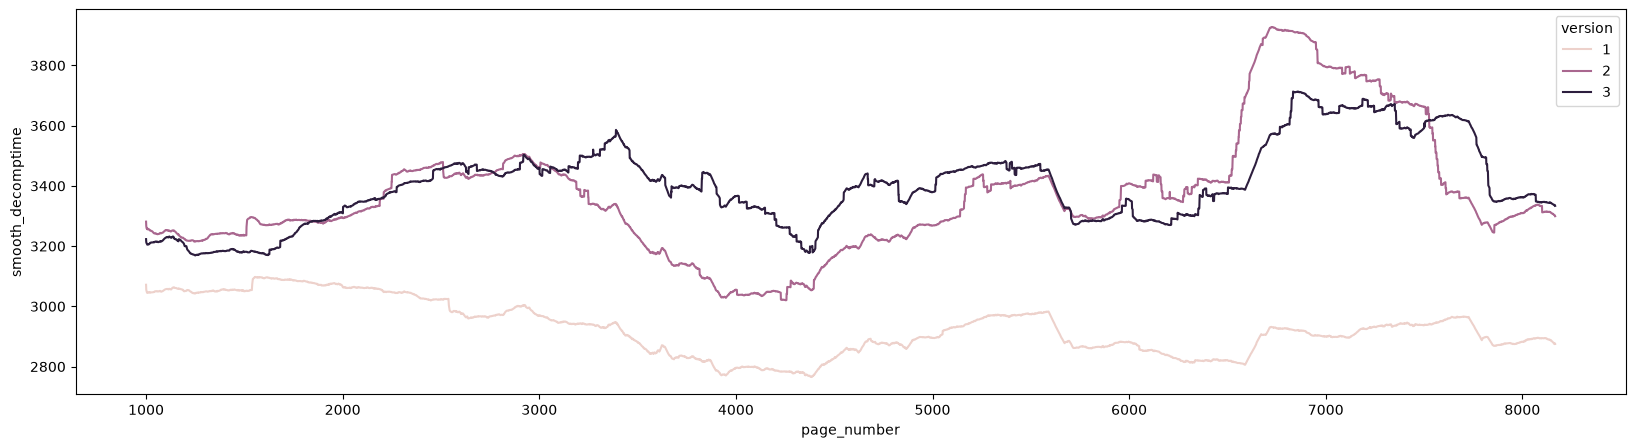

iterations,invalidation_method,page_number,compressed_size,uncompressed_size,compression_time,decompression_time,version,trace,alg,iter,inv,smooth_comptime,smooth_decomptime
i64,i64,i64,i64,i64,i64,i64,i32,str,str,str,str,f64,f64
1,1,1,2847,4096,73297,20248,1,"""spec-all""","""lz4""","""1""","""clflush""",null,null
1,1,2,3083,4096,24894,5954,1,"""spec-all""","""lz4""","""1""","""clflush""",null,null
1,1,3,3362,4096,26935,6024,1,"""spec-all""","""lz4""","""1""","""clflush""",null,null
1,1,4,2983,4096,23916,5598,1,"""spec-all""","""lz4""","""1""","""clflush""",null,null
1,1,5,3020,4096,22363,3011,1,"""spec-all""","""lz4""","""1""","""clflush""",null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…
null,null,8163,2739,4096,12955,4084,3,"""spec-all""","""lz4""","""1""","""clflush""",12107.365,3336.545
null,null,8164,1962,4096,11769,3620,3,"""spec-all""","""lz4""","""1""","""clflush""",12104.989,3336.997
null,null,8165,695,4096,6318,2767,3,"""spec-all""","""lz4""","""1""","""clflush""",12099.081,3336.272


In [31]:
df1 = df.filter(
    pl.col("alg") == "lz4",
    pl.col("inv") == "clflush"
).with_columns(
    pl.col("compression_time").rolling_mean(window_size=1000).over("version").alias("smooth_comptime")
).with_columns(
    pl.col("decompression_time").rolling_mean(window_size=1000).over("version").alias("smooth_decomptime")
)

""" df1 = df.filter(
    pl.col("trace_name") == "build-llvm",
    pl.col("alg_name") == "lz4",
    pl.col("cache_invalidation_method_decompress") == 0,
).with_columns(
    pl.col("compression_time").rolling_mean(window_size=1000, center=True).alias("smooth_comptime")
) """

plt.figure(figsize=(20,5))
sns.lineplot(
    df1,
    x="page_number",
    y="smooth_comptime",
    hue="version"
)
plt.show()

plt.figure(figsize=(20,5))
sns.lineplot(
    df1,
    x="page_number",
    y="smooth_decomptime",
    hue="version"
)
plt.show()

df1 